In [1]:
import sys
sys.path.append("/home/annierosen16")  # add directory with func.py
import pandas as pd
from func import cal_buoyancy
from sklearn.metrics import mean_squared_error
import glob
import os
import re
import traceback
from scipy.interpolate import interp1d
import requests
import datetime
import metpy.calc as mpcalc
from metpy.units import units
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from scipy.interpolate import interp1d
from scipy.optimize import bisect
import numpy as np
import pickle
import numpy as np
import math
import pint
from pydoc import help
import xarray as xr
import netCDF4 as nc
import re
import matplotlib.pyplot as plt
from numpy import load
from numpy import asarray
from numpy import save
import pytz
from scipy import stats
from sklearn.linear_model import LinearRegression
from collections import Counter
import pymannkendall as mk
%matplotlib inline

In [5]:
# reading in ERA5 specific humidity only (q)

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):
    
    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))
    
    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

q_files = get_files('specific_humidity', 'specific_humidity')

q_ds = xr.open_mfdataset(q_files, combine='by_coords', chunks={'time': 24})

# Select domain (lat 39→30, lon -105→-95)

q_sgp = q_ds.sel(
    
    latitude=slice(39, 30),
    
    longitude=slice(-105, -95)
)

# Shift time by -6 hours

q_sgp['time'] = q_sgp['time'] - pd.Timedelta(hours=6)

# Filter for warm-season months + ERA5 years

q_sgp = q_sgp.where(
    
    (q_sgp.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (q_sgp.time.dt.year.isin(range(2001, 2003))),
    
    drop=True
)

qdf = q_sgp.where(q_sgp.time.dt.hour == 15, drop=True)

qdf['time'].shape

(306,)

In [6]:
tz_path = '/home/annierosen16/data/era5sgp/era5_ml_temperature_and_geopotential_full_sgp'

file_pattern = f"{tz_path}/temperature_and_geopotential_*.nc"

all_files = glob.glob(file_pattern)

filtered_files = []

for f in all_files:
    
    basename = os.path.basename(f)
    
    date_str = basename.split("_")[-1].replace(".nc", "")  # YYYYMMDD
    
    year = int(date_str[0:4])
    
    month = int(date_str[4:6])  # extract MM

    if (year in [2001, 2002]) and (month in [5, 6, 7, 8, 9]):
        
        filtered_files.append(f)

# --- Load only filtered files ---

all_tz = xr.open_mfdataset(filtered_files, combine='by_coords', chunks={'time': 24})

# Pressure filter (≥ 50 hPa)

all_tz = all_tz.sel(pressure_level=all_tz.pressure_level >= 50)

# Shift valid_time by -6 hours

all_tz = all_tz.assign_coords(valid_time=all_tz.valid_time - pd.Timedelta(hours=6))

# Select only 15 UTC after shift

tzdf = all_tz.sel(valid_time=all_tz.valid_time[all_tz.valid_time.dt.hour == 15])

tzdf['valid_time'].shape

(306,)

In [7]:
# ERA5 information: surface pressure

sfc_pressure_path = '/data/rong4/Data/ERA5/3hourly/quvw_US/surface_pressure'

all_files = glob.glob(os.path.join(sfc_pressure_path, "era5.surface_pressure.*.nc"))

# Filter files for years 2001-2018 and months 5-9

filtered_files = [
    
    file for file in all_files 
    
    if 2001 <= int(os.path.basename(file).split(".")[2][:4]) <= 2002  
    
    and 5 <= int(os.path.basename(file).split(".")[2][4:]) <= 9       
]

all_sfc_p = xr.open_mfdataset(filtered_files, combine='by_coords')

all_sfc_p = all_sfc_p.sel(latitude=slice(39.0, 30.0), longitude=slice(-105.0, -95.0))

sfcp = all_sfc_p.assign_coords(time=all_sfc_p.time - pd.Timedelta(hours=6))

sfcp = sfcp.sel(time=sfcp.time[sfcp.time.dt.hour == 15])

sfcp['time'].shape

(306,)

In [8]:
# loading all necessary information for buoyancy 

g = 9.80665 # m/s^2

# 1 dimensional

times = qdf['time'].data

# 3 dimensional (time, lat, lon)

sp = sfcp['sp'].load().data / 100 # conversion to hPa

# 4 dimensional (time, pressure, lat, lon)

q = qdf['q'].sortby('level', ascending=False) * 1000 # conversion to g/kg, reversed to go from bottom to top

q = q.compute()

# 4 dimensional (time, pressure - reversed to go from bottom to top -, lat, lon)

t = tzdf['t'].load().data - 273.15 # conversion to Celsius

# 4 dimensional (time, pressure - reversed to go from bottom to top -, lat, lon)

z = tzdf['z'].load().data / g # geopotential height

# decreasing 39 -> 30 

lats = tzdf['latitude'].data

lons = tzdf['longitude'].data

In [9]:
# step 1 -> interpolate pressure to altitude

def interpolate_pressure_to_altitude(pres_array, alt_array, surface_pressure):
    
    x = alt_array
    
    y = pres_array

    f = interp1d(x, y, assume_sorted=False, fill_value="extrapolate")

    max_x = np.nanmax(x)
    
    min_x = np.nanmin(x)

    xint = np.arange(min_x, max_x, 20)

    # Interpolate pressure against new altitude intervals
    
    yint = f(xint) * units.hPa
    
    yint = yint.magnitude  # Extract numerical values

    # Compute altitude above surface
    
    mask = yint <= surface_pressure
    
    xnew = xint[mask]
    
    ynew = yint[mask]

    if xnew.size == 0:
        
        return np.array([]), np.array([]), np.nan 

    sfc_alt = xnew[0]  # Define surface altitude before adjusting xnew
    
    xnew_rel = xnew - sfc_alt

    # Apply single mask to keep values within 5000m AGL
    
    valid_mask = xnew_rel <= 6000 # meters AGL
    
    xclean = xnew_rel[valid_mask]
    
    if xclean[-1] != 6000:
        
        print(xclean[-1])
    
    yclean = ynew[valid_mask]

    return yclean, sfc_alt

In [10]:
# for all days (at 15 LST), latitudes & longitudes: interpolate pressure 

num_levels = 301 # equivalent to 6000 meters AGL for every gridpoint

num_times = times.shape[0]

# oriented bottom to top 

pres_array = qdf['level'].data[::-1]

interpolated_pressure = np.full((num_times, num_levels, lats.shape[0], lons.shape[0]), np.nan)

# surface_altitudes captures geopotential height at the surface for all times and gridpoints

surface_altitudes = np.full((num_times, lats.shape[0], lons.shape[0]), np.nan)

for tidx in range(times.shape[0]):
    
    print(times[tidx])
    
    for latidx in range(lats.shape[0]):

        for lonidx in range(lons.shape[0]):
            
            # bottom to top

            alt_array = z[tidx, :, latidx, lonidx]

            sfc_pres = sp[tidx, latidx, lonidx]

            new_pres, sfc_alt = interpolate_pressure_to_altitude(pres_array, alt_array, sfc_pres)
            
            interpolated_pressure[tidx, :, latidx, lonidx] = new_pres
            
            surface_altitudes[tidx, latidx, lonidx] = sfc_alt

2001-05-01T15:00:00.000000000
2001-05-02T15:00:00.000000000
2001-05-03T15:00:00.000000000
2001-05-04T15:00:00.000000000
2001-05-05T15:00:00.000000000
2001-05-06T15:00:00.000000000
2001-05-07T15:00:00.000000000
2001-05-08T15:00:00.000000000
2001-05-09T15:00:00.000000000
2001-05-10T15:00:00.000000000
2001-05-11T15:00:00.000000000
2001-05-12T15:00:00.000000000
2001-05-13T15:00:00.000000000
2001-05-14T15:00:00.000000000
2001-05-15T15:00:00.000000000
2001-05-16T15:00:00.000000000
2001-05-17T15:00:00.000000000
2001-05-18T15:00:00.000000000
2001-05-19T15:00:00.000000000
2001-05-20T15:00:00.000000000
2001-05-21T15:00:00.000000000
2001-05-22T15:00:00.000000000
2001-05-23T15:00:00.000000000
2001-05-24T15:00:00.000000000
2001-05-25T15:00:00.000000000
2001-05-26T15:00:00.000000000
2001-05-27T15:00:00.000000000
2001-05-28T15:00:00.000000000
2001-05-29T15:00:00.000000000
2001-05-30T15:00:00.000000000
2001-05-31T15:00:00.000000000
2001-06-01T15:00:00.000000000
2001-06-02T15:00:00.000000000
2001-06-03

2002-08-30T15:00:00.000000000
2002-08-31T15:00:00.000000000
2002-09-01T15:00:00.000000000
2002-09-02T15:00:00.000000000
2002-09-03T15:00:00.000000000
2002-09-04T15:00:00.000000000
2002-09-05T15:00:00.000000000
2002-09-06T15:00:00.000000000
2002-09-07T15:00:00.000000000
2002-09-08T15:00:00.000000000
2002-09-09T15:00:00.000000000
2002-09-10T15:00:00.000000000
2002-09-11T15:00:00.000000000
2002-09-12T15:00:00.000000000
2002-09-13T15:00:00.000000000
2002-09-14T15:00:00.000000000
2002-09-15T15:00:00.000000000
2002-09-16T15:00:00.000000000
2002-09-17T15:00:00.000000000
2002-09-18T15:00:00.000000000
2002-09-19T15:00:00.000000000
2002-09-20T15:00:00.000000000
2002-09-21T15:00:00.000000000
2002-09-22T15:00:00.000000000
2002-09-23T15:00:00.000000000
2002-09-24T15:00:00.000000000
2002-09-25T15:00:00.000000000
2002-09-26T15:00:00.000000000
2002-09-27T15:00:00.000000000
2002-09-28T15:00:00.000000000
2002-09-29T15:00:00.000000000
2002-09-30T15:00:00.000000000


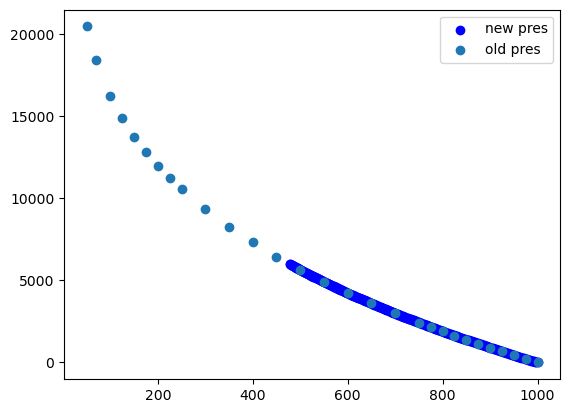

In [13]:
# for all days (at 15 LST), latitudes & longitudes: interpolate pressure 

# surface_altitudes captures geopotential height at the surface for all times and gridpoints

tidx = 0
    
latidx = -1

lonidx = -1

pres_array = qdf['level'].data[::-1]

alt_array = z[tidx, :, latidx, lonidx]

sfc_pres = sp[tidx, latidx, lonidx]

# new_pres, sfc_alt = interpolate_pressure_to_altitude(pres_array, alt_array, sfc_pres) 

new_pres = interpolated_pressure[tidx, :, latidx, lonidx]

sfc_alt = surface_altitudes[tidx, latidx, lonidx]

alt_array_adj = alt_array - sfc_alt

new_alt = np.arange(0, 6000 + 20, 20)   # 301 points

plt.scatter(new_pres, new_alt, label='new pres', color='blue')

plt.scatter(pres_array, alt_array_adj, label='old pres')

plt.legend()

plt.show()

In [12]:
# cleaner version

def interpolate_var_to_altitude(variable_to_interpolate, alt_array, sfc_alt):
    
    x = alt_array
    
    y = variable_to_interpolate

    f = interp1d(x, y, assume_sorted=False, fill_value="extrapolate")

    max_x = np.nanmax(x)
    
    min_x = np.nanmin(x)

    xnew = np.arange(min_x, max_x, 20)
    
    ynew = f(xnew)

    # Compute relative altitude
    
    xnew_rel = xnew - sfc_alt
    
    valid_mask = np.logical_and(xnew_rel >= 0, xnew_rel <= 6000)

    yfinal = ynew[valid_mask]
    
    xfinal = xnew_rel[valid_mask]

    return yfinal

In [19]:
# tidx = 0

# latidx = -1

# lonidx = -1

# q_array = q[tidx, :, latidx, lonidx]

# alt_array = z[tidx, :, latidx, lonidx]

# sfc_alt = surface_altitudes[tidx, latidx, lonidx]

# new_q = interpolated_q[tidx, :, latidx, lonidx]

# plt.scatter(new_q, new_alt, label='new q', color='blue')

# plt.plot(q_array, alt_array-sfc_alt, label='old q')

# plt.show()

In [15]:
# interpolation of specific humidity 

num_levels = 301 # equivalent to 6000 meters AGL for every gridpoint

num_times = times.shape[0]

interpolated_q = np.full((num_times, num_levels, lats.shape[0], lons.shape[0]), np.nan)

for tidx in range(times.shape[0]):
    
    print(times[tidx])

    for latidx in range(lats.shape[0]):
        
        for lonidx in range(lons.shape[0]):
            
            q_array = q[tidx, :, latidx, lonidx]

            alt_array = z[tidx, :, latidx, lonidx]

            sfc_alt = surface_altitudes[tidx, latidx, lonidx]

            new_q = interpolate_var_to_altitude(q_array, alt_array, sfc_alt)

            interpolated_q[tidx, :, latidx, lonidx] = new_q

2001-05-01T15:00:00.000000000
2001-05-02T15:00:00.000000000
2001-05-03T15:00:00.000000000
2001-05-04T15:00:00.000000000
2001-05-05T15:00:00.000000000
2001-05-06T15:00:00.000000000
2001-05-07T15:00:00.000000000
2001-05-08T15:00:00.000000000
2001-05-09T15:00:00.000000000
2001-05-10T15:00:00.000000000
2001-05-11T15:00:00.000000000
2001-05-12T15:00:00.000000000
2001-05-13T15:00:00.000000000
2001-05-14T15:00:00.000000000
2001-05-15T15:00:00.000000000
2001-05-16T15:00:00.000000000
2001-05-17T15:00:00.000000000
2001-05-18T15:00:00.000000000
2001-05-19T15:00:00.000000000
2001-05-20T15:00:00.000000000
2001-05-21T15:00:00.000000000
2001-05-22T15:00:00.000000000
2001-05-23T15:00:00.000000000
2001-05-24T15:00:00.000000000
2001-05-25T15:00:00.000000000
2001-05-26T15:00:00.000000000
2001-05-27T15:00:00.000000000
2001-05-28T15:00:00.000000000
2001-05-29T15:00:00.000000000
2001-05-30T15:00:00.000000000
2001-05-31T15:00:00.000000000
2001-06-01T15:00:00.000000000
2001-06-02T15:00:00.000000000
2001-06-03

2002-08-30T15:00:00.000000000
2002-08-31T15:00:00.000000000
2002-09-01T15:00:00.000000000
2002-09-02T15:00:00.000000000
2002-09-03T15:00:00.000000000
2002-09-04T15:00:00.000000000
2002-09-05T15:00:00.000000000
2002-09-06T15:00:00.000000000
2002-09-07T15:00:00.000000000
2002-09-08T15:00:00.000000000
2002-09-09T15:00:00.000000000
2002-09-10T15:00:00.000000000
2002-09-11T15:00:00.000000000
2002-09-12T15:00:00.000000000
2002-09-13T15:00:00.000000000
2002-09-14T15:00:00.000000000
2002-09-15T15:00:00.000000000
2002-09-16T15:00:00.000000000
2002-09-17T15:00:00.000000000
2002-09-18T15:00:00.000000000
2002-09-19T15:00:00.000000000
2002-09-20T15:00:00.000000000
2002-09-21T15:00:00.000000000
2002-09-22T15:00:00.000000000
2002-09-23T15:00:00.000000000
2002-09-24T15:00:00.000000000
2002-09-25T15:00:00.000000000
2002-09-26T15:00:00.000000000
2002-09-27T15:00:00.000000000
2002-09-28T15:00:00.000000000
2002-09-29T15:00:00.000000000
2002-09-30T15:00:00.000000000


In [21]:
# interpolation of temperature 

num_levels = 301 # equivalent to 4000 meters AGL for every gridpoint

num_times = times.shape[0]

interpolated_t = np.full((num_times, num_levels, lats.shape[0], lons.shape[0]), np.nan)

for tidx in range(times.shape[0]):
    
    print(times[tidx])

    for latidx in range(lats.shape[0]):

        for lonidx in range(lons.shape[0]):
            
            t_array = t[tidx, :, latidx, lonidx]

            alt_array = z[tidx, :, latidx, lonidx]

            sfc_alt = surface_altitudes[tidx, latidx, lonidx]

            new_t = interpolate_var_to_altitude(t_array, alt_array, sfc_alt)

            interpolated_t[tidx, :, latidx, lonidx] = new_t

2001-05-01T15:00:00.000000000
2001-05-02T15:00:00.000000000
2001-05-03T15:00:00.000000000
2001-05-04T15:00:00.000000000
2001-05-05T15:00:00.000000000
2001-05-06T15:00:00.000000000
2001-05-07T15:00:00.000000000
2001-05-08T15:00:00.000000000
2001-05-09T15:00:00.000000000
2001-05-10T15:00:00.000000000
2001-05-11T15:00:00.000000000
2001-05-12T15:00:00.000000000
2001-05-13T15:00:00.000000000
2001-05-14T15:00:00.000000000
2001-05-15T15:00:00.000000000
2001-05-16T15:00:00.000000000
2001-05-17T15:00:00.000000000
2001-05-18T15:00:00.000000000
2001-05-19T15:00:00.000000000
2001-05-20T15:00:00.000000000
2001-05-21T15:00:00.000000000
2001-05-22T15:00:00.000000000
2001-05-23T15:00:00.000000000
2001-05-24T15:00:00.000000000
2001-05-25T15:00:00.000000000
2001-05-26T15:00:00.000000000
2001-05-27T15:00:00.000000000
2001-05-28T15:00:00.000000000
2001-05-29T15:00:00.000000000
2001-05-30T15:00:00.000000000
2001-05-31T15:00:00.000000000
2001-06-01T15:00:00.000000000
2001-06-02T15:00:00.000000000
2001-06-03

2002-08-30T15:00:00.000000000
2002-08-31T15:00:00.000000000
2002-09-01T15:00:00.000000000
2002-09-02T15:00:00.000000000
2002-09-03T15:00:00.000000000
2002-09-04T15:00:00.000000000
2002-09-05T15:00:00.000000000
2002-09-06T15:00:00.000000000
2002-09-07T15:00:00.000000000
2002-09-08T15:00:00.000000000
2002-09-09T15:00:00.000000000
2002-09-10T15:00:00.000000000
2002-09-11T15:00:00.000000000
2002-09-12T15:00:00.000000000
2002-09-13T15:00:00.000000000
2002-09-14T15:00:00.000000000
2002-09-15T15:00:00.000000000
2002-09-16T15:00:00.000000000
2002-09-17T15:00:00.000000000
2002-09-18T15:00:00.000000000
2002-09-19T15:00:00.000000000
2002-09-20T15:00:00.000000000
2002-09-21T15:00:00.000000000
2002-09-22T15:00:00.000000000
2002-09-23T15:00:00.000000000
2002-09-24T15:00:00.000000000
2002-09-25T15:00:00.000000000
2002-09-26T15:00:00.000000000
2002-09-27T15:00:00.000000000
2002-09-28T15:00:00.000000000
2002-09-29T15:00:00.000000000
2002-09-30T15:00:00.000000000


In [24]:
# tidx = 5

# latidx = 20

# lonidx = 5

# t_array = t[tidx, :, latidx, lonidx]

# alt_array = z[tidx, :, latidx, lonidx]

# sfc_alt = surface_altitudes[tidx, latidx, lonidx]

# # new_t = interpolate_var_to_altitude(t_array, alt_array, sfc_alt)

# new_t = interpolated_t[tidx, :, latidx, lonidx]

# plt.scatter(new_t, new_alt, label='new t', color='blue')

# plt.plot(t_array, alt_array-sfc_alt, label='old t')

# plt.show()

In [25]:
# creation of q_fit profiles -> for every gridpoint and everyday, calculate the 0-1km ("mixed layer") average q

# the collection of all these average qs across time for each gridpoint is the xinput to the regression

# then, for each height, collect all q values for all times -> this is your y_target

# the lr model is trained on x input and y input and returns a prediction for q values at that height

# note that q_fit is equivalent to original q profiles below 2km

interpolated_altitudes = np.arange(0, 6000 + 20, 20)  

n_times = interpolated_q.shape[0]  

n_altitudes = len(interpolated_altitudes) 

n_lats = lats.shape[0]  

n_lons = lons.shape[0]  

interpolated_qfit = np.full((n_times, n_altitudes, n_lats, n_lons), np.nan, dtype=np.float32)

for latidx in range(n_lats):
    
    for lonidx in range(n_lons):
        
        print(lats[latidx], lons[lonidx])
        
        # extracts all q profiles for a given gridpoint across time series 
        
        q_array = interpolated_q[:, :, latidx, lonidx]  # shape (time, levels)
        
        # define indices for bottom 1km and 2km
        
        bottom_1km_idx = interpolated_altitudes <= 1000
        
        bottom_2km_idx = interpolated_altitudes <= 2000
        
        target_idx = (interpolated_altitudes > 2000) & (interpolated_altitudes <= 6000)  # heights to predict

        # compute near-surface q (mean of bottom 1km for every profile in time series)
        
        near_surface_q = np.mean(q_array[:, bottom_1km_idx], axis=1).reshape(-1, 1) # shape = (time)

        lr = LinearRegression()

        # copy q_array and retain observed values up to 2km
        
        q_fit = q_array.copy()
        
        q_fit[:, ~bottom_2km_idx] = np.nan  # Keep observed q below 2km

        # loop over target heights (above 2km) and perform regression
        
        for j, idx in enumerate(np.where(target_idx)[0]):
            
            y_target = q_array[:, idx].reshape(-1, 1)  # Shape (2754, 1)
            
            # train regression model
            
            lr.fit(near_surface_q, y_target)
            
            # Predict q_fit values for this height and assign them to the large array
            
            q_fit[:, idx] = lr.predict(near_surface_q).flatten()

        # append the q_fit for this lat, lon position into the big array
        
        interpolated_qfit[:, :, latidx, lonidx] = q_fit

print(interpolated_qfit.shape)

39.0 -105.0
39.0 -104.75
39.0 -104.5
39.0 -104.25
39.0 -104.0
39.0 -103.75
39.0 -103.5
39.0 -103.25
39.0 -103.0
39.0 -102.75
39.0 -102.5
39.0 -102.25
39.0 -102.0
39.0 -101.75
39.0 -101.5
39.0 -101.25
39.0 -101.0
39.0 -100.75
39.0 -100.5
39.0 -100.25
39.0 -100.0
39.0 -99.75
39.0 -99.5
39.0 -99.25
39.0 -99.0
39.0 -98.75
39.0 -98.5
39.0 -98.25
39.0 -98.0
39.0 -97.75
39.0 -97.5
39.0 -97.25
39.0 -97.0
39.0 -96.75
39.0 -96.5
39.0 -96.25
39.0 -96.0
39.0 -95.75
39.0 -95.5
39.0 -95.25
39.0 -95.0
38.75 -105.0
38.75 -104.75
38.75 -104.5
38.75 -104.25
38.75 -104.0
38.75 -103.75
38.75 -103.5
38.75 -103.25
38.75 -103.0
38.75 -102.75
38.75 -102.5
38.75 -102.25
38.75 -102.0
38.75 -101.75
38.75 -101.5
38.75 -101.25
38.75 -101.0
38.75 -100.75
38.75 -100.5
38.75 -100.25
38.75 -100.0
38.75 -99.75
38.75 -99.5
38.75 -99.25
38.75 -99.0
38.75 -98.75
38.75 -98.5
38.75 -98.25
38.75 -98.0
38.75 -97.75
38.75 -97.5
38.75 -97.25
38.75 -97.0
38.75 -96.75
38.75 -96.5
38.75 -96.25
38.75 -96.0
38.75 -95.75
38.75 -95.5


35.0 -104.75
35.0 -104.5
35.0 -104.25
35.0 -104.0
35.0 -103.75
35.0 -103.5
35.0 -103.25
35.0 -103.0
35.0 -102.75
35.0 -102.5
35.0 -102.25
35.0 -102.0
35.0 -101.75
35.0 -101.5
35.0 -101.25
35.0 -101.0
35.0 -100.75
35.0 -100.5
35.0 -100.25
35.0 -100.0
35.0 -99.75
35.0 -99.5
35.0 -99.25
35.0 -99.0
35.0 -98.75
35.0 -98.5
35.0 -98.25
35.0 -98.0
35.0 -97.75
35.0 -97.5
35.0 -97.25
35.0 -97.0
35.0 -96.75
35.0 -96.5
35.0 -96.25
35.0 -96.0
35.0 -95.75
35.0 -95.5
35.0 -95.25
35.0 -95.0
34.75 -105.0
34.75 -104.75
34.75 -104.5
34.75 -104.25
34.75 -104.0
34.75 -103.75
34.75 -103.5
34.75 -103.25
34.75 -103.0
34.75 -102.75
34.75 -102.5
34.75 -102.25
34.75 -102.0
34.75 -101.75
34.75 -101.5
34.75 -101.25
34.75 -101.0
34.75 -100.75
34.75 -100.5
34.75 -100.25
34.75 -100.0
34.75 -99.75
34.75 -99.5
34.75 -99.25
34.75 -99.0
34.75 -98.75
34.75 -98.5
34.75 -98.25
34.75 -98.0
34.75 -97.75
34.75 -97.5
34.75 -97.25
34.75 -97.0
34.75 -96.75
34.75 -96.5
34.75 -96.25
34.75 -96.0
34.75 -95.75
34.75 -95.5
34.75 -95.25

31.0 -104.5
31.0 -104.25
31.0 -104.0
31.0 -103.75
31.0 -103.5
31.0 -103.25
31.0 -103.0
31.0 -102.75
31.0 -102.5
31.0 -102.25
31.0 -102.0
31.0 -101.75
31.0 -101.5
31.0 -101.25
31.0 -101.0
31.0 -100.75
31.0 -100.5
31.0 -100.25
31.0 -100.0
31.0 -99.75
31.0 -99.5
31.0 -99.25
31.0 -99.0
31.0 -98.75
31.0 -98.5
31.0 -98.25
31.0 -98.0
31.0 -97.75
31.0 -97.5
31.0 -97.25
31.0 -97.0
31.0 -96.75
31.0 -96.5
31.0 -96.25
31.0 -96.0
31.0 -95.75
31.0 -95.5
31.0 -95.25
31.0 -95.0
30.75 -105.0
30.75 -104.75
30.75 -104.5
30.75 -104.25
30.75 -104.0
30.75 -103.75
30.75 -103.5
30.75 -103.25
30.75 -103.0
30.75 -102.75
30.75 -102.5
30.75 -102.25
30.75 -102.0
30.75 -101.75
30.75 -101.5
30.75 -101.25
30.75 -101.0
30.75 -100.75
30.75 -100.5
30.75 -100.25
30.75 -100.0
30.75 -99.75
30.75 -99.5
30.75 -99.25
30.75 -99.0
30.75 -98.75
30.75 -98.5
30.75 -98.25
30.75 -98.0
30.75 -97.75
30.75 -97.5
30.75 -97.25
30.75 -97.0
30.75 -96.75
30.75 -96.5
30.75 -96.25
30.75 -96.0
30.75 -95.75
30.75 -95.5
30.75 -95.25
30.75 -95.0


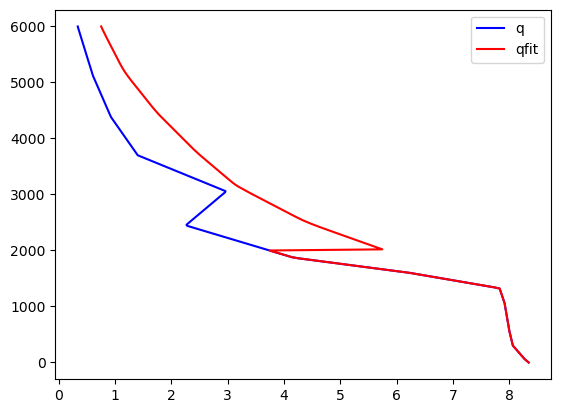

In [26]:
tidx = 0

latidx = 0 

lonidx = -18 

plt.plot(interpolated_q[tidx, :, latidx, lonidx], interpolated_altitudes, color='blue', label='q')

plt.plot(interpolated_qfit[tidx, :, latidx, lonidx], interpolated_altitudes, color='red', label='qfit')

plt.legend()

plt.show()

In [27]:
# Step 1: Define the backup directory in your home folder

backup_dir = os.path.expanduser("~/backup_data")  # Expands ~ to full home directory path

os.makedirs(backup_dir, exist_ok=True)  # create the directory if it doesn't exist

# Step 3: Save multiple arrays in a compressed file

# file_path = os.path.join(backup_dir, "backup_arrays_for_buoyancy.npz")  # Full path to save file

file_path = os.path.join(backup_dir, "backup_arrays_for_buoyancy_15lst_2001_2002_6km_agl.npz")  # Full path to save file

np.savez_compressed(file_path, 
                    
                    interpolated_pressure=interpolated_pressure, 
                    
                    interpolated_q=interpolated_q, 
                    
                    interpolated_t=interpolated_t,
                    
                    interpolated_qfit=interpolated_qfit)

print(f"Arrays saved to {file_path}")

# Step 4: Verify that the file exists

print("Saved files:", os.listdir(backup_dir))

Arrays saved to /home/annierosen16/backup_data/backup_arrays_for_buoyancy_15lst_2001_2002_6km_agl.npz
Saved files: ['backup_arrays_for_buoyancy.npz', 'backup_metadata_for_buoyancy.npz', 'ctp_hilow_input_arrays.npz', 'backup_arrays_for_advection.npz', 'ml_q_9am.nc', 'backup_arrays_for_buoyancy_15lst.npz', 'backup_metadata_for_buoyancy_15lst.npz', 'backup_arrays_for_buoyancy_15lst_2001_2002_6km_agl.npz']


In [28]:
backup_dir = os.path.expanduser("~/backup_data")

os.makedirs(backup_dir, exist_ok=True)  # Ensure the directory exists

# file_path = os.path.join(backup_dir, "backup_metadata_for_buoyancy.npz")

file_path = os.path.join(backup_dir, "backup_metadata_for_buoyancy_15lst_2001_2002_6km_agl.npz")

np.savez(file_path, 
         
         times=times, 
         
         lats=lats, 
         
         lons=lons)

print(f"Backup saved at {file_path}")

Backup saved at /home/annierosen16/backup_data/backup_metadata_for_buoyancy_15lst_2001_2002_6km_agl.npz
